# Venue Popular Times Coverage

**Scope**: `healthcare` + `restroom` only.  
**Goal**: print DB counts, SerpAPI coverage, and Popular Times counts; keep charts in the notebook.

> ⚠️ API warning: this notebook is **offline-only**. It reads cached CSV/JSON outputs from `Data+ML/test/6.22-6.27/output` and does **not** call SerpAPI. Do not run `src/venue_serpapi.py` unless you intentionally want live API calls and quota usage.

> 📦 **Module structure** (2026-06-29 refactor): `geo_utils.py` (Haversine), `serpapi_client.py` (SerpAPI client), `venue_serpapi.py` (legacy facade). All `import venue_serpapi as vs` calls continue to work unchanged.

In [1]:
from pathlib import Path
import sys
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project')
MODULE_DIR = PROJECT_ROOT / 'Data+ML/test/6.22-6.27/src'
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from populartimes_coverage_summary import build_summary_bundle, default_paths

paths = default_paths(PROJECT_ROOT)
for key in ['venue_file', 'label_file', 'metadata_file']:
    print(f'{key}: {paths[key]}')

venue_file: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.8-6.12_DB/tests/output/venues_clean.csv
label_file: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.22-6.27/output/venue_label_status_coverage_view.csv
metadata_file: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.22-6.27/output/run_metadata.json


## 1. Load Cached Outputs

In [2]:
bundle = build_summary_bundle(
    venue_file=paths['venue_file'],
    label_file=paths['label_file'],
    metadata_file=paths['metadata_file'],
)

venues = bundle['venues']
db_scope = bundle['db_scope']
label_scope = bundle['label_scope']
meta = bundle['metadata']

print(f'Total DB venues: {len(venues):,}')
print(f'In-scope DB venues: {len(db_scope):,}')
print(f'SerpAPI label rows for scope: {len(label_scope):,}')
print(f'Unmatched in-scope DB venues: {bundle["unmatched_in_scope_count"]:,}')

Total DB venues: 4,838
In-scope DB venues: 1,559
SerpAPI label rows for scope: 1,559
Unmatched in-scope DB venues: 0


## 2. Core Coverage Table

In [3]:
type_summary = bundle['type_summary']
type_summary

,venue_type,db_count,serpapi_checked,serpapi_coverage_pct_of_db,has_popular_times,popular_times_pct_of_db,popular_times_pct_of_checked
0,healthcare,1086,743,68.4,161,14.8,21.7
1,restroom,473,37,7.8,8,1.7,21.6
2,TOTAL,1559,780,50.0,169,10.8,21.7


## 3. Label Status Breakdown

In [4]:
status_breakdown = bundle['status_breakdown']
status_breakdown

label_status,venue_type,api_not_checked,has_popular_times,no_popular_times,search_not_matched,total
0,healthcare,0,161,582,343,1086
1,restroom,436,8,29,0,473


### Restroom ML Feasibility Note

Restroom venues are retained in the coverage audit, but they are not suitable for ML training in the current dataset.

- Only **8 restroom venues** have `popular_times` labels, which is far below the sample size needed for a reliable supervised busyness model.
- Most matched restroom venues are located inside parks or park-adjacent facilities, so their usage pattern is likely driven by local park activity, opening hours, event context, and pedestrian micro-location rather than general city traffic.
- Traffic and weather features may still be useful as weak contextual signals, but their relationship to restroom busyness is expected to be much weaker and less stable than for healthcare venues.
- Therefore, restroom should remain in the coverage report for transparency, but should use rule-based fallback or be excluded from the ML training set until substantially more labeled `popular_times` data is available.


## 4. District View

In [5]:
district_summary = bundle['district_summary']
district_summary

,district,venue_type,db_count,serpapi_checked,has_popular_times,serpapi_coverage_pct_of_db,popular_times_pct_of_db
0,downtown,healthcare,429,308,83,71.8,19.3
1,downtown,restroom,137,17,2,12.4,1.5
2,midtown_east,healthcare,303,210,38,69.3,12.5
3,midtown_east,restroom,93,12,1,12.9,1.1
4,midtown_west,healthcare,168,133,23,79.2,13.7
5,midtown_west,restroom,49,8,5,16.3,10.2
6,uptown,healthcare,186,92,17,49.5,9.1
7,uptown,restroom,136,0,0,0.0,0.0


## 5. Charts

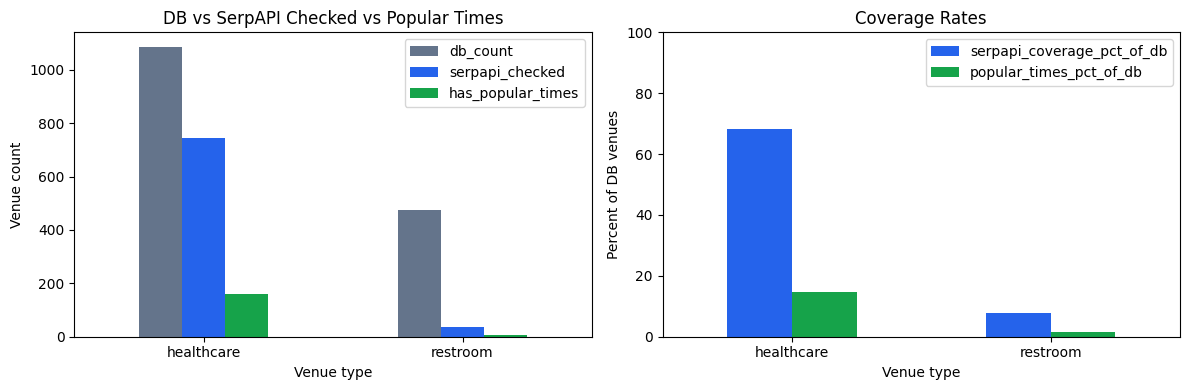

In [6]:
plot_df = type_summary[type_summary['venue_type'] != 'TOTAL'].set_index('venue_type')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df[['db_count', 'serpapi_checked', 'has_popular_times']].plot(
    kind='bar', ax=axes[0], color=['#64748b', '#2563eb', '#16a34a']
)
axes[0].set_title('DB vs SerpAPI Checked vs Popular Times')
axes[0].set_xlabel('Venue type')
axes[0].set_ylabel('Venue count')
axes[0].tick_params(axis='x', rotation=0)

plot_df[['serpapi_coverage_pct_of_db', 'popular_times_pct_of_db']].plot(
    kind='bar', ax=axes[1], color=['#2563eb', '#16a34a']
)
axes[1].set_title('Coverage Rates')
axes[1].set_xlabel('Venue type')
axes[1].set_ylabel('Percent of DB venues')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Run Metadata

In [7]:
print(f"Run ID: {meta.get('run_id')}")
print(f"Timestamp: {meta.get('timestamp')}")

usage = meta.get('serpapi_usage', {})
print(
    'SerpAPI calls already spent in cached run:',
    usage.get('total_calls'),
    f"(search={usage.get('search_calls')}, place={usage.get('place_calls')})",
)
print('Monthly quota remaining at run time:', usage.get('monthly_quota_remaining'))

results = meta.get('results', {})
print('Discovered venues:', results.get('total_discovered'))
print('Discovered with popular_times:', results.get('with_popular_times'))

Run ID: 20260628T224231Z
Timestamp: 2026-06-28T22:42:31.359740+00:00
SerpAPI calls already spent in cached run: 0 (search=0, place=0)
Monthly quota remaining at run time: 250
Discovered venues: 80
Discovered with popular_times: 30


## 7. Write Back To DB

This step is offline and does not call SerpAPI. It writes the final healthcare grouping back to MySQL for deployment reuse.

In [8]:
from write_healthcare_prediction_groups_to_db import run_writeback

WRITE_TO_DB = False
db_write_summary = run_writeback(live=WRITE_TO_DB)
db_write_summary


Healthcare rows to update: 1086
Dry-run only. No database writes will be made.


{'venues_updated': 0}